##**Quantum Chemistry Coding for PolyhaQ Event (part 2)! Let's Go!**
<center>
<img src="https://media.istockphoto.com/id/2269775481/fr/photo/grand-groupe-de-mod%C3%A8les-mol%C3%A9culaires-se-d%C3%A9pla%C3%A7ant-le-long-dune-forme-de-boucle-infinie.jpg?s=612x612&w=0&k=20&c=0nIfdQohzVMiAfp55mZUHi_mzJsDKq9loJ0qMUhJtlQ=" width="850">
</center>
Reference of Image: www.istockphoto.com


**Building Molecular Hamiltonian in Pennylane**


The electronic wave function $\Psi(r)$ satisfies the Schrödinger equation

$$H_{e}\Psi(r)=E\Psi(r)$$

where $H_{e}$ and $\Psi(r)$ denote the electronic Hamiltonian and the total energy of the molecule, respectively. Solving the latter equation relies on the Born–Oppenheimer approximation, where the nuclei are treated as stationary point charges. As a result, both the total energy and the electronic Hamiltonian depend on the nuclear positions only through parameters.

In [ ]:
import numpy as np

symbols = ["H", "O", "H"]
coordinates = np.array([[-0.0399, -0.0038, 0.0], [1.5780, 0.8540, 0.0], [2.7909, -0.5159, 0.0]])

In [ ]:
!pip install pennylane
from pennylane import qchem

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 108.0 MB/s eta 0:00:00


Import the molecular geometry from an external file:

In [ ]:
%%writefile h2o.xyz
3

O 0.000000 0.000000 0.000000
H 0.000000 -0.757000 0.587000
H 0.000000  0.757000 0.587000

Writing h2o.xyz


In [ ]:
symbols, coordinates = qchem.read_structure("h2o.xyz")

print(symbols)
print(coordinates)

['O', 'H', 'H']
[ 0.          0.          0.          0.         -1.43052268  1.10926924
  0.          1.43052268  1.10926924]


**Molecular Orbitals and Coulomb Integrals**

Molecular orbitals in quantum chemistry describe single-electron wave functions in a molecule. They are typically formed as linear combinations of atomic orbitals, with coefficients calculated using the Hartree–Fock method. In this approach, each electron moves independently under the influence of the nuclei and an averaged field from the other electrons. The resulting optimized coefficients are then used to construct the second-quantized Hamiltonian.

---

In second quantization, the electronic wave function is represented in the occupation-number basis, where each spin-orbital is labeled by its occupation. The electronic Hamiltonian is expressed as

\begin{equation}
H =
\sum_{pq} h_{pq}\, a_p^\dagger a_q
+\frac{1}{2}\sum_{pqrs} h_{pqrs}\,
a_p^\dagger a_q^\dagger a_r a_s ,
\end{equation}

where $a_p^\dagger$ and $a_p$ are the fermionic creation and annihilation operators, respectively, and $h_{pq}$ and $h_{pqrs}$ are the one- and two-electron Coulomb integrals computed from Hartree-Fock orbitals.

To encode this basis on a quantum computer, the fermionic operators are mapped onto qubit operators using the Jordan-Wigner, Bravyi-Kitaev, and Parity transformation. This procedure decomposes the molecular Hamiltonian into a linear combination of Pauli strings,

\begin{equation}
H = \sum_i c_i P_i,
\qquad
P_i \in \{I,X,Y,Z\}^{\otimes n},
\end{equation}

where $c_i$ are real coefficients and $P_i$ are tensor products of Pauli operators acting on $n$ qubits.

---

In PennyLane, the molecular\_hamiltonian() function automates the construction of the qubit Hamiltonian.

For instance, for water molecule, we have:


In [ ]:
molecule = qchem.Molecule(symbols, coordinates)
H, qubits = qchem.molecular_hamiltonian(molecule)
print("Number of qubits: {:}".format(qubits))
print("Qubit Hamiltonian")
print(H)

Number of qubits: 14
Qubit Hamiltonian
-46.42307638549974 * I([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]) + 12.413469827262176 * Z(0) + -0.12505447734568192 * (Y(0) @ Z(1) @ Y(2)) + -0.12505447734568192 * (X(0) @ Z(1) @ X(2)) + -0.04276476188135304 * (Y(0) @ Z(1) @ Z(2) @ Z(3) @ Z(4) @ Z(5) @ Y(6)) + -0.04276476188135304 * (X(0) @ Z(1) @ Z(2) @ Z(3) @ Z(4) @ Z(5) @ X(6)) + -0.0726183658426841 * (Y(0) @ Z(1) @ Z(2) @ Z(3) @ Z(4) @ Z(5) @ Z(6) @ Z(7) @ Z(8) @ Z(9) @ Y(10)) + -0.0726183658426841 * (X(0) @ Z(1) @ Z(2) @ Z(3) @ Z(4) @ Z(5) @ Z(6) @ Z(7) @ Z(8) @ Z(9) @ X(10)) + 1.6564550458125176 * Z(2) + 0.2366003111030314 * (Z(0) @ Z(2)) + -0.11927485620769585 * (Y(2) @ Z(3) @ Z(4) @ Z(5) @ Y(6)) + -0.11927485620769585 * (X(2) @ Z(3) @ Z(4) @ Z(5) @ X(6)) + -0.02650809120035361 * (Z(0) @ Y(2) @ Z(3) @ Z(4) @ Z(5) @ Y(6)) + -0.02650809120035361 * (Z(0) @ X(2) @ Z(3) @ Z(4) @ Z(5) @ X(6)) + -0.2841068649911443 * (Y(2) @ Z(3) @ Z(4) @ Z(5) @ Z(6) @ Z(7) @ Z(8) @ Z(9) @ Y(10)) + -0.284106

**Simulation Parameters and Active Space Selection**

To construct the molecular Hamiltonian, several physical and computational parameters must be specified. For the water molecule, a neutral electronic configuration was assumed by setting the molecular charge to

\begin{equation}
\texttt{charge} = 0.
\end{equation}

---

**Spin Multiplicity**

The spin multiplicity determines the total spin state of the system that obtained from:

$$2S + 1.$$

For instance, since the ten electrons of the water molecule occupy the five lowest-energy molecular orbitals in pairs, the ground-state Hartree-Fock reference corresponds to a singlet state with

\begin{equation}
\texttt{multiplicity} = 1.
\end{equation}

<center>
<img src="https://blog-assets.cloud.pennylane.ai/demos/tutorial_quantum_chemistry/main/_assets/images/hf_references.png?w=1920" width="550">
</center>

Reference of Image: pennylane.ai

**Basis Set**

Molecular orbitals are expanded as linear combinations of Gaussian-type atomic orbitals. In this work, the minimal STO-3G basis set was employed,

\begin{equation}
\textbf{basis_set} = \textbf{"sto-3g"},
\end{equation}

which provides a compact representation suitable for proof-of-concept quantum simulations.

---

**Active Space Approximation**

To reduce the computational resources required for quantum simulation, an active-space approximation was adopted. In this approach, molecular orbitals are divided into three groups:


- **Core orbitals:** always doubly occupied.
- **Active orbitals:** allowed to change occupation during the simulation.
- **External orbitals:** assumed to remain unoccupied.


The number of active spin-orbitals directly determines the number of qubits required for the quantum computation.

For the water molecule in the STO-3G basis, there are ten electrons distributed among seven molecular orbitals. A symmetric active space consisting of four active electrons and four active orbitals was selected, providing a balance between computational efficiency and accuracy.

---

The corresponding PennyLane implementation is shown below:

<center>
<img src="https://blog-assets.cloud.pennylane.ai/demos/tutorial_quantum_chemistry/main/_assets/images/sketch_active_space.png?w=1920" width="450">
</center>
Reference of Image: pennylane.ai

**Important Point: The number of active spin-orbitals determines the number of qubits required to perform the quantum simulations.:**

In [ ]:
molecule = qchem.Molecule(
    symbols,
    coordinates,
    charge=0,
    mult=1,
    basis_name="sto-3g"
)

H, qubits = qchem.molecular_hamiltonian(
    molecule,
    active_electrons=4,
    active_orbitals=4,
)

print("Number of qubits required to perform quantum simulations: {:}".format(qubits))
print("Hamiltonian of the water molecule")
print(H)

Number of qubits required to perform quantum simulations: 8
Hamiltonian of the water molecule
-73.11371306233829 * I([0, 1, 2, 3, 4, 5, 6, 7]) + 0.22844487726495322 * Z(0) + 0.22844487726495336 * Z(1) + 0.1956185632883195 * (Z(0) @ Z(1)) + 0.17487052947586657 * Z(2) + 0.1682226242280055 * (Z(0) @ Z(2)) + 0.18220029148414363 * (Z(1) @ Z(2)) + 0.013977667256138165 * (Y(0) @ X(1) @ X(2) @ Y(3)) + -0.013977667256138165 * (Y(0) @ Y(1) @ X(2) @ X(3)) + -0.013977667256138165 * (X(0) @ X(1) @ Y(2) @ Y(3)) + 0.013977667256138165 * (X(0) @ Y(1) @ Y(2) @ X(3)) + 0.1748705294758666 * Z(3) + 0.18220029148414363 * (Z(0) @ Z(3)) + 0.1682226242280055 * (Z(1) @ Z(3)) + 0.2200397724026304 * (Z(2) @ Z(3)) + 0.04257452829034327 * (Y(0) @ Z(1) @ Z(2) @ Z(3) @ Y(4)) + 0.04257452829034327 * (X(0) @ Z(1) @ Z(2) @ Z(3) @ X(4)) + -0.1640006977156219 * Z(4) + 0.12007583827221481 * (Z(0) @ Z(4)) + 0.030361157595314284 * (Y(0) @ Z(2) @ Z(3) @ Y(4)) + 0.030361157595314284 * (X(0) @ Z(2) @ Z(3) @ X(4)) + 0.029527712

**Alternative Hamiltonian Construction Backend**

In addition to the default differentiable workflow, PennyLane can generate molecular Hamiltonians using the OpenFermion-PySCF backend. First, the required dependency must be installed:

In [ ]:
!pip install openfermionpyscf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 74.5 MB/s eta 0:00:00



The molecular Hamiltonian can then be constructed using the PySCF backend as follows:


In [ ]:
from pennylane import qchem
import numpy as np

# =========================
# Define geometry FIRST
# =========================
coordinates = np.array([
    [0.000000,  0.000000,  0.000000],   # O
    [0.000000, -0.757000,  0.587000],   # H
    [0.000000,  0.757000,  0.587000]    # H
])

symbols = ["O", "H", "H"]

# =========================
# Build molecule
# =========================
molecule = qchem.Molecule(
    symbols=symbols,
    coordinates=coordinates,
    charge=0,
    mult=1,
    basis_name="sto-3g"
)

# =========================
# Hamiltonian
# =========================
H, qubits = qchem.molecular_hamiltonian(
    molecule,
    method="pyscf"
)

print("Number of qubits:", qubits)
print(H)

# =========================
# Hartree-Fock energy
# =========================
hf_energy = qchem.hf_energy(molecule)()

print(f"Hartree-Fock Energy: {hf_energy:.8f} Ha")

Number of qubits: 14
-41.660451335377765 * I([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]) + 12.688326779855503 * Z(0) + 0.13865185907077457 * (Y(0) @ Z(1) @ Y(2)) + 0.13865185907077457 * (X(0) @ Z(1) @ X(2)) + -0.05124865146865024 * (Y(0) @ Z(1) @ Z(2) @ Z(3) @ Z(4) @ Z(5) @ Y(6)) + -0.05124865146865024 * (X(0) @ Z(1) @ Z(2) @ Z(3) @ Z(4) @ Z(5) @ X(6)) + 0.08453162609318694 * (Y(0) @ Z(1) @ Z(2) @ Z(3) @ Z(4) @ Z(5) @ Z(6) @ Z(7) @ Z(8) @ Z(9) @ Y(10)) + 0.08453162609318694 * (X(0) @ Z(1) @ Z(2) @ Z(3) @ Z(4) @ Z(5) @ Z(6) @ Z(7) @ Z(8) @ Z(9) @ X(10)) + 2.0057520199422028 * Z(2) + 0.257452607422153 * (Z(0) @ Z(2)) + 0.0011285858182666464 * (Y(2) @ Z(3) @ Z(4) @ Z(5) @ Y(6)) + 0.0011285858182666464 * (X(2) @ Z(3) @ Z(4) @ Z(5) @ X(6)) + -0.003084418757124079 * (Z(0) @ Y(2) @ Z(3) @ Z(4) @ Z(5) @ Y(6)) + -0.003084418757124079 * (Z(0) @ X(2) @ Z(3) @ Z(4) @ Z(5) @ X(6)) + -0.3206865262613476 * (Y(2) @ Z(3) @ Z(4) @ Z(5) @ Z(6) @ Z(7) @ Z(8) @ Z(9) @ Y(10)) + -0.3206865262613476 * (X(

This method interfaces with the PySCF electronic-structure package through the OpenFermion–PySCF plugin.

Hamiltonians generated independently using OpenFermion can be directly imported into PennyLane as observables.

**Why PySCF?**


- **Accurate quantum chemistry calculations**
- **Supports a wide range of basis sets**
- **Allows the use of active spaces to reduce computational cost**
- **Integrates directly with PennyLane quantum workflows**
- **Widely used and validated in quantum chemistry research**

Without PySCF, PennyLane would not know the molecular integrals needed to build the Hamiltonian.

##**Obtaining the Potensial Eneregy Surface (PES) for $H_{2}$ as a toy molecule using Variational Quantum Eigensolver (VQE) algorithm.**

**Let's go step by step in Pennylane!**

1. **Building the electronic Hamiltonian**:

In [ ]:
!pip install pennylane
from jax import numpy as np
import jax
import pennylane as qp
import pennylane as qml

In [ ]:
jax.config.update("jax_platform_name", "cpu")
jax.config.update('jax_enable_x64', True)

dataset = qp.data.load('qchem', molname="H2")[0]
H, qubits = dataset.hamiltonian, len(dataset.hamiltonian.wires)
print("Number of qubits = ", qubits)
print("The Hamiltonian is ", H)

Number of qubits =  4
The Hamiltonian is  -0.09963387941370971 * I(0) + 0.17110545123720233 * Z(0) + 0.17110545123720225 * Z(1) + 0.16859349595532533 * (Z(0) @ Z(1)) + 0.04533062254573469 * (Y(0) @ X(1) @ X(2) @ Y(3)) + -0.04533062254573469 * (Y(0) @ Y(1) @ X(2) @ X(3)) + -0.04533062254573469 * (X(0) @ X(1) @ Y(2) @ Y(3)) + 0.04533062254573469 * (X(0) @ Y(1) @ Y(2) @ X(3)) + -0.22250914236600539 * Z(2) + 0.12051027989546245 * (Z(0) @ Z(2)) + -0.22250914236600539 * Z(3) + 0.16584090244119712 * (Z(0) @ Z(3)) + 0.16584090244119712 * (Z(1) @ Z(2)) + 0.12051027989546245 * (Z(1) @ Z(3)) + 0.1743207725924201 * (Z(2) @ Z(3))


2. **Implement the VQE algorithm**

In [ ]:
dev = qp.device("lightning.qubit", wires=qubits)

The initial state is:

$$|\psi(θ)⟩ = cos(θ/2)|1100⟩ - sin(θ/2)|0011⟩.$$

Choose the Jordan-Wigner mapping.

<center>
<img src="https://blog-assets.cloud.pennylane.ai/demos/tutorial_vqe/main/_assets/images/sketch_circuit.png?w=1920" width="650">
</center>
Reference of Image: pennylane.ai

**Givens Rotation**


A Givens rotation is a simple operation that rotates only **two selected quantum states** inside a larger system, while leaving all other states unchanged.

It is widely used in quantum chemistry circuits to build particle-preserving quantum operations.

---

**Intuition**

Think of a quantum system with states like:

- |01⟩  
- |10⟩  
- |00⟩  
- |11⟩  

A Givens rotation only mixes **two of them**, for example:

$$|01⟩ \leftrightarrow |10⟩$$

It behaves like a normal 2D rotation.

---

**Mathematical Form**

A rotation with angle θ acts as:


$$|01\rangle \rightarrow \cos(\theta/2)|01\rangle + \sin(\theta/2)|10\rangle$$

$$|10\rangle \rightarrow \cos(\theta/2)|10\rangle - \sin(\theta/2)|01\rangle$$

All other states remain unchanged.

This preserves important physical quantities like **particle number (electron number)**.

---

**Why It Is Important in Quantum Chemistry?**

In quantum chemistry simulations:

- electrons must be conserved
- arbitrary rotations can break physical rules

So we use Givens rotations.

For more information, please see: https://pennylane.ai/demos/tutorial_givens_rotations.

In [ ]:
electrons = 2
hf = qp.qchem.hf_state(electrons, qubits)
print(hf)

[1 1 0 0]


In [ ]:
@qp.qnode(dev, interface="jax")
def circuit(param, wires):
    qp.BasisState(hf, wires=wires)
    qp.DoubleExcitation(param, wires=[0, 1, 2, 3])
    return qp.expval(H)

This is the simplest UCCSD-type excitation used in VQE.

In [ ]:
def cost_fn(param):
    return circuit(param, wires=range(qubits))

In [ ]:
import optax

max_iterations = 100
conv_tol = 1e-06

opt = optax.sgd(learning_rate=0.4)

The SGD (Stochastic Gradient Descent) update rule is:

$$\theta_{new} =\theta_{old} − \eta \frac{∂E}{∂\theta}.$$

In [ ]:
theta = np.array(0.)

# store the values of the cost function
energy = [cost_fn(theta)]

# store the values of the circuit parameter
angle = [theta]

opt_state = opt.init(theta)

for n in range(max_iterations):

    gradient = jax.grad(cost_fn)(theta)
    updates, opt_state = opt.update(gradient, opt_state)
    theta = optax.apply_updates(theta, updates)

    angle.append(theta)
    energy.append(cost_fn(theta))

    conv = np.abs(energy[-1] - energy[-2])

    if n % 2 == 0:
        print(f"Step = {n},  Energy = {energy[-1]:.8f} Ha")

    if conv <= conv_tol:
        break

print("\n" f"Final value of the ground-state energy = {energy[-1]:.8f} Ha")
print("\n" f"Optimal value of the circuit parameter = {angle[-1]:.4f}")

Step = 0,  Energy = -1.12772109 Ha
Step = 2,  Energy = -1.13524628 Ha
Step = 4,  Energy = -1.13683932 Ha
Step = 6,  Energy = -1.13717430 Ha
Step = 8,  Energy = -1.13724463 Ha
Step = 10,  Energy = -1.13725940 Ha
Step = 12,  Energy = -1.13726250 Ha

Final value of the ground-state energy = -1.13726250 Ha

Optimal value of the circuit parameter = 0.2250


For SGD:

$$Δθ=−\eta \frac{dE}{dE}.$$

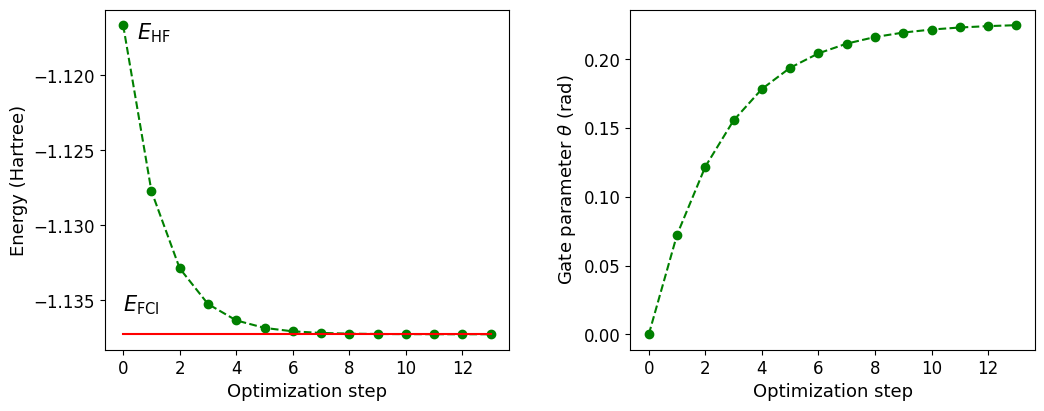

In [ ]:
import matplotlib.pyplot as plt
dataset = qml.data.load("qchem", molname="H2")[0]

fig = plt.figure()
fig.set_figheight(5)
fig.set_figwidth(12)

# Full configuration interaction (FCI) energy computed classically
E_fci = dataset.fci_energy

# Add energy plot on column 1
ax1 = fig.add_subplot(121)
ax1.plot(range(n + 2), energy, "go", ls="dashed")
ax1.plot(range(n + 2), np.full(n + 2, E_fci), color="red")
ax1.set_xlabel("Optimization step", fontsize=13)
ax1.set_ylabel("Energy (Hartree)", fontsize=13)
ax1.text(0.5, -1.1176, r"$E_\mathrm{HF}$", fontsize=15)
ax1.text(0, -1.1357, r"$E_\mathrm{FCI}$", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add angle plot on column 2
ax2 = fig.add_subplot(122)
ax2.plot(range(n + 2), angle, "go", ls="dashed")
ax2.set_xlabel("Optimization step", fontsize=13)
ax2.set_ylabel("Gate parameter $\\theta$ (rad)", fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.subplots_adjust(wspace=0.3, bottom=0.2)
plt.show()